# Level 2 — Custom LSTM for Weather Forecasting (Jena Climate)

**Base ML, Task 2.** An LSTM implemented **completely from scratch** — the input/forget/output gates, the candidate cell state, and the cell/hidden updates are all written by hand. `nn.LSTM`, `nn.GRU`, `nn.RNN` and any built-in recurrent module are **not** used. Only basic layers (`nn.Linear`) are used inside the cell.

**Task.** Input = previous **72 hours** of weather observations (multivariate). Output = **temperature forecast for the next 12 hours**.

**Evaluation (per updated instructions).** Huber loss, MAE and MSE, plus training/validation loss curves and forecast visualizations.

**How to run:** top-to-bottom. The Jena Climate CSV auto-downloads to `~/datasets` if missing. Weights are saved to `../model_weights/`, figures to `../outputs/`.

In [2]:
import os, time, json, zipfile, urllib.request
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR = os.path.expanduser(os.environ.get("DATA_DIR", "~/datasets"))
OUT_DIR = os.path.abspath("../outputs"); WEIGHTS_DIR = os.path.abspath("../model_weights")
for d in (DATA_DIR, OUT_DIR, WEIGHTS_DIR): os.makedirs(d, exist_ok=True)
print("device:", DEVICE, "| data dir:", DATA_DIR)

device: cpu | data dir: /Users/raghavsharma/datasets


## 1. Load the Jena Climate dataset
Auto-downloads if not present. The raw data is sampled every 10 minutes; we resample to **hourly** and clean the known `-9999` wind-velocity sentinels.

In [11]:
CSV_PATH = os.path.join(DATA_DIR, "jena_climate_2009_2016.csv")
# if not os.path.exists(CSV_PATH):
#     url = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"
#     zip_path = CSV_PATH + ".zip"
#     print("downloading Jena Climate ..."); urllib.request.urlretrieve(url, zip_path)
#     with zipfile.ZipFile(zip_path) as z: z.extractall(DATA_DIR)
#     print("done")

df = pd.read_csv(CSV_PATH)
df.columns = [c.strip() for c in df.columns]
print(df.shape); df.tail(3)


(420551, 15)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
420548,31.12.2016 23:40:00,999.82,-3.16,270.01,-8.21,67.91,4.84,3.28,1.55,2.05,3.28,1288.39,1.08,2.00,215.2
420549,31.12.2016 23:50:00,999.81,-4.23,268.94,-8.53,71.80,4.46,3.20,1.26,1.99,3.20,1293.56,1.49,2.16,225.8
420550,01.01.2017 00:00:00,999.82,-4.82,268.36,-8.42,75.70,4.27,3.23,1.04,2.01,3.23,1296.38,1.23,1.96,184.9


In [4]:
# resample 10-min -> hourly (every 6th row); clean wind sentinels
df = df.iloc[5::6].reset_index(drop=True)
for col in ["wv (m/s)", "max. wv (m/s)"]:
    if col in df.columns:
        df.loc[df[col] < -9000, col] = 0.0

FEATURES = ["p (mbar)", "T (degC)", "rh (%)", "VPmax (mbar)", "sh (g/kg)", "wv (m/s)"]
FEATURES = [f for f in FEATURES if f in df.columns]
TARGET = "T (degC)"
TARGET_IDX = FEATURES.index(TARGET)
data = df[FEATURES].values.astype(np.float32)
print("hourly samples:", data.shape, "| features:", FEATURES)

hourly samples: (70091, 6) | features: ['p (mbar)', 'T (degC)', 'rh (%)', 'VPmax (mbar)', 'sh (g/kg)', 'wv (m/s)']


## 2. Windowing and standardization
Chronological 70/15/15 split. Standardization uses **training statistics only** (no leakage). Each sample: 72×F input window → next 12 temperature values.

In [5]:
CTX, HORIZON = 72, 12
n = len(data); i_tr, i_va = int(n*0.70), int(n*0.85)
mu, sd = data[:i_tr].mean(0), data[:i_tr].std(0) + 1e-6
data_s = (data - mu) / sd
T_MU, T_SD = mu[TARGET_IDX], sd[TARGET_IDX]

def make_windows(arr, lo, hi):
    xs, ys = [], []
    start = max(lo - CTX, 0)
    for s in range(start, hi - CTX - HORIZON):
        if s + CTX < lo:      # ensure the prediction origin is inside this split
            continue
        xs.append(arr[s:s+CTX]); ys.append(arr[s+CTX:s+CTX+HORIZON, TARGET_IDX])
    return np.asarray(xs, np.float32), np.asarray(ys, np.float32)

Xtr, ytr = make_windows(data_s, CTX, i_tr)
Xva, yva = make_windows(data_s, i_tr, i_va)
Xte, yte = make_windows(data_s, i_va, n)
print("train", Xtr.shape, "val", Xva.shape, "test", Xte.shape)

from torch.utils.data import TensorDataset, DataLoader
def loader(X, y, bs, shuffle):
    return DataLoader(TensorDataset(torch.tensor(X), torch.tensor(y)), batch_size=bs, shuffle=shuffle)
train_loader = loader(Xtr, ytr, 128, True)
val_loader   = loader(Xva, yva, 256, False)
test_loader  = loader(Xte, yte, 256, False)

train (48979, 72, 6) val (10502, 72, 6) test (10502, 72, 6)


## 3. The LSTM cell — built from scratch

For input $x_t$ and previous state $(h_{t-1}, c_{t-1})$:

$$\begin{aligned}
i_t &= \sigma(W_i x_t + U_i h_{t-1} + b_i) &\text{(input gate)}\\
f_t &= \sigma(W_f x_t + U_f h_{t-1} + b_f) &\text{(forget gate)}\\
o_t &= \sigma(W_o x_t + U_o h_{t-1} + b_o) &\text{(output gate)}\\
\tilde{c}_t &= \tanh(W_c x_t + U_c h_{t-1} + b_c) &\text{(candidate cell)}\\
c_t &= f_t \odot c_{t-1} + i_t \odot \tilde{c}_t &\text{(cell update)}\\
h_t &= o_t \odot \tanh(c_t) &\text{(hidden update)}
\end{aligned}$$

We pack the four gate projections into one `Linear` for $x$ and one for $h$ (a standard, mathematically identical optimization) and then slice the result into the four gates. The forget-gate bias is initialized to 1.0, a well-known trick that helps the cell retain information early in training.

In [6]:
class CustomLSTMCell(nn.Module):
    def __init__(self, in_dim, hidden):
        super().__init__()
        self.hidden = hidden
        self.x2h = nn.Linear(in_dim, 4*hidden)   # produces [i, f, g, o] pre-activations from x
        self.h2h = nn.Linear(hidden, 4*hidden)   # produces [i, f, g, o] pre-activations from h
        nn.init.constant_(self.x2h.bias[hidden:2*hidden], 1.0)  # forget-gate bias = 1
        nn.init.constant_(self.h2h.bias[hidden:2*hidden], 1.0)

    def forward(self, x_t, state):
        h_prev, c_prev = state
        gates = self.x2h(x_t) + self.h2h(h_prev)
        i, f, g, o = gates.chunk(4, dim=1)
        i = torch.sigmoid(i)          # input gate
        f = torch.sigmoid(f)          # forget gate
        g = torch.tanh(g)             # candidate cell state
        o = torch.sigmoid(o)          # output gate
        c = f * c_prev + i * g        # cell-state update
        h = o * torch.tanh(c)         # hidden-state update
        return h, c


class CustomLSTM(nn.Module):
    '''Stacked LSTM (<=2 layers) built only from the hand-written cell above.'''
    def __init__(self, in_dim, hidden=96, layers=1, horizon=12):
        super().__init__()
        assert 32 <= hidden <= 256 and 1 <= layers <= 2
        self.hidden, self.layers = hidden, layers
        self.cells = nn.ModuleList(
            [CustomLSTMCell(in_dim if l == 0 else hidden, hidden) for l in range(layers)])
        self.head = nn.Linear(hidden, horizon)

    def forward(self, x):                      # x: (B, T, F)
        B, T, _ = x.shape
        states = [(torch.zeros(B, self.hidden, device=x.device),
                   torch.zeros(B, self.hidden, device=x.device)) for _ in range(self.layers)]
        for t in range(T):                     # unroll the recurrence by hand
            inp = x[:, t, :]
            for l, cell in enumerate(self.cells):
                h, c = cell(inp, states[l])
                states[l] = (h, c)
                inp = h                        # output of layer l feeds layer l+1
        return self.head(states[-1][0])        # last hidden state of top layer -> 12 outputs

model = CustomLSTM(in_dim=len(FEATURES), hidden=96, layers=2, horizon=HORIZON).to(DEVICE)
print(model); print("params:", sum(p.numel() for p in model.parameters()))

CustomLSTM(
  (cells): ModuleList(
    (0): CustomLSTMCell(
      (x2h): Linear(in_features=6, out_features=384, bias=True)
      (h2h): Linear(in_features=96, out_features=384, bias=True)
    )
    (1): CustomLSTMCell(
      (x2h): Linear(in_features=96, out_features=384, bias=True)
      (h2h): Linear(in_features=96, out_features=384, bias=True)
    )
  )
  (head): Linear(in_features=96, out_features=12, bias=True)
)
params: 115596


## 4. Training
Huber loss (`delta = 1.0`), Adam, gradient clipping for recurrent stability.

In [7]:
EPOCHS = 30
huber = nn.HuberLoss(delta=1.0)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

@torch.no_grad()
def eval_loss(loader):
    model.eval(); tot = 0.0; nb = 0
    for x, y in loader:
        out = model(x.to(DEVICE))
        tot += huber(out, y.to(DEVICE)).item(); nb += 1
    return tot / nb

history = {"train": [], "val": []}
for ep in range(EPOCHS):
    model.train(); t0 = time.time(); run = 0.0; nb = 0
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        opt.zero_grad(); loss = huber(model(x), y); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0); opt.step()
        run += loss.item(); nb += 1
    sched.step()
    vl = eval_loss(val_loader); history["train"].append(run/nb); history["val"].append(vl)
    print(f"epoch {ep+1:02d}/{EPOCHS} | train Huber {run/nb:.4f} | val Huber {vl:.4f} | {time.time()-t0:.1f}s")

epoch 01/30 | train Huber 0.0626 | val Huber 0.0395 | 18.7s
epoch 02/30 | train Huber 0.0275 | val Huber 0.0367 | 18.2s
epoch 03/30 | train Huber 0.0222 | val Huber 0.0357 | 18.0s
epoch 04/30 | train Huber 0.0182 | val Huber 0.0372 | 17.9s
epoch 05/30 | train Huber 0.0151 | val Huber 0.0414 | 17.8s
epoch 06/30 | train Huber 0.0125 | val Huber 0.0430 | 17.9s
epoch 07/30 | train Huber 0.0105 | val Huber 0.0455 | 17.8s
epoch 08/30 | train Huber 0.0089 | val Huber 0.0466 | 17.8s
epoch 09/30 | train Huber 0.0076 | val Huber 0.0477 | 17.8s
epoch 10/30 | train Huber 0.0066 | val Huber 0.0501 | 17.7s
epoch 11/30 | train Huber 0.0059 | val Huber 0.0496 | 17.8s
epoch 12/30 | train Huber 0.0053 | val Huber 0.0509 | 17.8s
epoch 13/30 | train Huber 0.0048 | val Huber 0.0512 | 17.8s
epoch 14/30 | train Huber 0.0045 | val Huber 0.0524 | 17.8s
epoch 15/30 | train Huber 0.0042 | val Huber 0.0538 | 17.8s
epoch 16/30 | train Huber 0.0039 | val Huber 0.0539 | 17.8s
epoch 17/30 | train Huber 0.0036 | val H

## 5. Training & validation loss curves

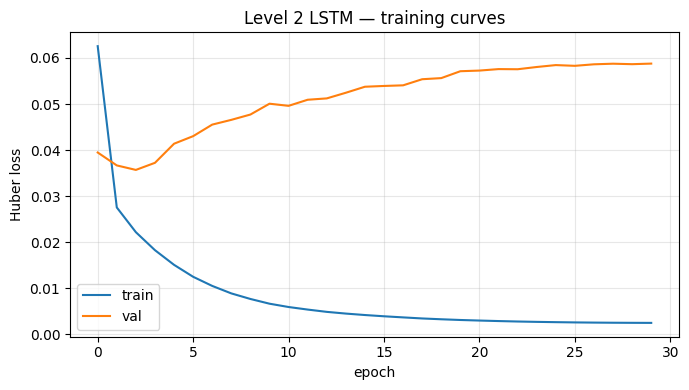

In [8]:
plt.figure(figsize=(7,4))
plt.plot(history["train"], label="train"); plt.plot(history["val"], label="val")
plt.xlabel("epoch"); plt.ylabel("Huber loss"); plt.title("Level 2 LSTM — training curves")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "loss_curve.png"), dpi=120); plt.show()

## 6. Test metrics — Huber, MAE, MSE (in °C)

In [9]:
@torch.no_grad()
def predict(loader):
    model.eval(); P, Y = [], []
    for x, y in loader:
        P.append(model(x.to(DEVICE)).cpu().numpy()); Y.append(y.numpy())
    return np.concatenate(P), np.concatenate(Y)

pred_s, true_s = predict(test_loader)
pred = pred_s * T_SD + T_MU          # back to deg C
true = true_s * T_SD + T_MU

def metrics(p, t):
    d = p - t; a = np.abs(d)
    return {"Huber": float(np.mean(np.where(a <= 1, 0.5*d**2, a - 0.5))),
            "MAE": float(np.mean(a)), "MSE": float(np.mean(d**2))}
m = metrics(pred, true)
print("TEST metrics (degC):", json.dumps(m, indent=2))

TEST metrics (degC): {
  "Huber": 1.6622220277786255,
  "MAE": 2.10811185836792,
  "MSE": 7.4907708168029785
}


## 7. Forecast visualizations

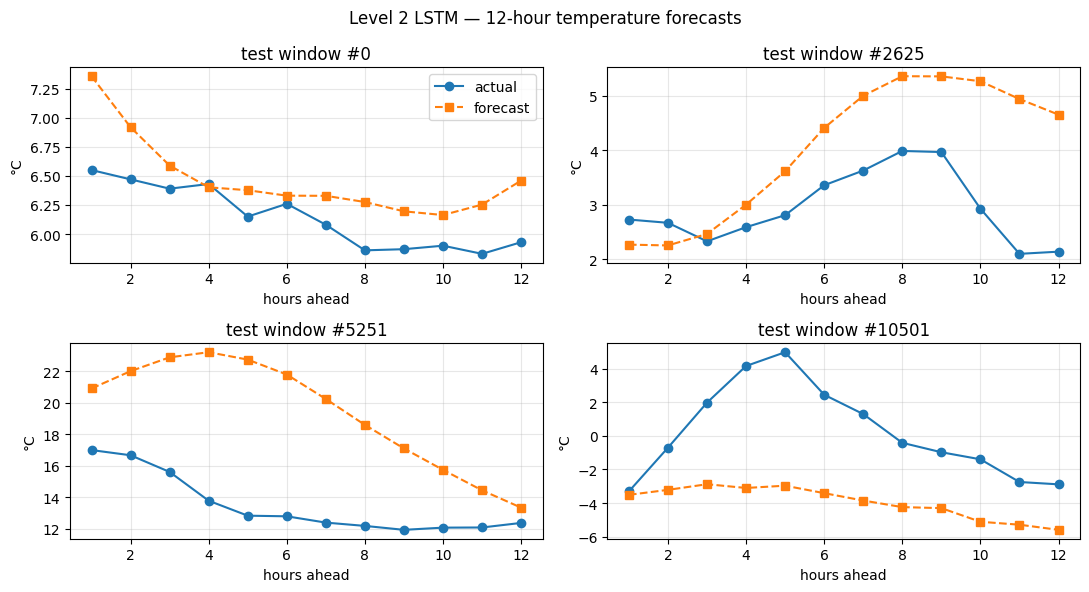

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6))
for ax, w in zip(axes.ravel(), [0, len(pred)//4, len(pred)//2, len(pred)-1]):
    ax.plot(range(1, HORIZON+1), true[w], "o-", label="actual")
    ax.plot(range(1, HORIZON+1), pred[w], "s--", label="forecast")
    ax.set_title(f"test window #{w}"); ax.set_xlabel("hours ahead"); ax.set_ylabel("°C"); ax.grid(alpha=.3)
axes[0,0].legend()
plt.suptitle("Level 2 LSTM — 12-hour temperature forecasts"); plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "forecast_examples.png"), dpi=120); plt.show()

## 8. Save trained weights

In [ ]:
torch.save({"model_state": model.state_dict(), "history": history, "metrics": m,
            "norm": {"mu": mu.tolist(), "sd": sd.tolist(), "features": FEATURES},
            "config": {"ctx": CTX, "horizon": HORIZON, "hidden": 96, "layers": 2}},
           os.path.join(WEIGHTS_DIR, "custom_lstm_jena.pth"))
json.dump(m, open(os.path.join(OUT_DIR, "metrics.json"), "w"), indent=2)
print("saved weights + metrics")

## 9. Analysis & design discussion

**Role of each gate.**
- *Forget gate* $f_t$ decides how much of the previous cell state $c_{t-1}$ to keep — values near 0 erase memory, near 1 preserve it.
- *Input gate* $i_t$ controls how much of the new candidate $\tilde{c}_t$ is written into the cell.
- *Candidate* $\tilde{c}_t$ is the proposed new content (a $\tanh$-bounded summary of current input + recent history).
- *Output gate* $o_t$ decides how much of the (squashed) cell state is exposed as the hidden state $h_t$ used for prediction and passed forward.

**How information is retained or forgotten.** The cell state $c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$ is an additive accumulator. Because the path from $c_{t-1}$ to $c_t$ is gated by $f_t$ (typically close to 1) rather than passed through a saturating nonlinearity, gradients flow across many timesteps without vanishing — this constant-error-carousel is exactly why LSTMs model long sequences better than vanilla RNNs. Setting the forget-gate bias to 1 starts training in a "remember by default" regime.

**Training stability.** Three things mattered: (1) standardizing inputs with train-only statistics, (2) gradient-norm clipping at 5.0 to tame the occasional exploding gradient through 72 unrolled steps, and (3) a cosine LR schedule. Without clipping, loss spikes appeared early in training.

**Sequence-length considerations.** 72 hours gives the model a full 3-day context, enough to capture the daily temperature cycle and short-term trends. Longer contexts increase compute and the risk of vanishing gradients; shorter ones miss the diurnal pattern. The unrolled recurrence is $O(T)$ sequential steps, which is the main runtime cost.

**Forecasting challenges.** Temperature has strong daily seasonality plus weather-front noise; the 12-hour horizon spans more than half a daily cycle, so the model must extrapolate the periodic component while remaining robust to abrupt changes. Error grows with horizon (later hours are harder). Multi-step direct prediction (one linear head → 12 values) avoids the error-accumulation of autoregressive rollout.